# B19 · BeyondArena, contamination and moving benchmarks

<p class="subtitle">Research bridge · Core ★ · One win: decide whether two results answer the same question</p>

[B18a](https://avistian.github.io/relational/lessons/b18a-context-state.html) showed that fixed weights do not fix a predictor: support, preprocessing and inference settings also matter. Now imagine a leaderboard improves next month. Did the model improve, did the test change, or did the evaluation replace missing runs? Before interpreting the score, identify the experiment.

This serves our mission directly. A relational model must beat a strong baseline under the information and split rules of its intended deployment. A high rank on unrelated public tables does not settle that comparison.

[Student notebook](https://avistian.github.io/relational/labs/b19-benchmark-evidence.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/b19-benchmark-evidence.html) · [Download solution](https://avistian.github.io/relational/labs/solutions/b19-benchmark-evidence.ipynb) · [Printable reference](https://avistian.github.io/relational/reference/b19-benchmark-evidence.html) · [Reproduction contract](https://avistian.github.io/relational/labs/b19-reproduction.md) · [Source audit](https://avistian.github.io/relational/labs/evidence/b19/source-audit.json)

## 1 · Start with the question, then choose the split

Recall [grouped validation](https://avistian.github.io/relational/lessons/0004-grouped-nested-cv.html) and [B18a's predictor identity](https://avistian.github.io/relational/lessons/b18a-context-state.html). Without looking back: what may be fitted using test labels? Does changing the support change the predictor? Are two rows from the same person independent evidence about performance on a new person?



**In plain terms.** A test split is a promise about what will be unfamiliar at deployment. A random split with familiar customers tests a different promise from holding out whole customers.

An **IID** assumption treats observations as independent draws from the same distribution. A **grouped split** keeps every row of each group together, so test groups are absent from training. A **temporal split** puts the test period after training. Choose according to the intended prediction, not according to which split produces the best score. Grouped and temporal structure may coexist: a future-customer task may need both boundaries. All features and labels must also have been available at the query's cutoff. [BeyondArena §2](https://arxiv.org/html/2606.30410v1#S2)

**Worked example.** Customer A has eight visits and one customer-level label. If six visits enter training and two enter test, remembering A's training label can succeed without learning how to predict for a new customer. That may be useful for a familiar-customer task if those labels are legally available. It is the wrong evaluation for unseen customers.

<section class="evidence-flow" aria-label="Evaluation computation"><div class="evidence-step"><strong>1 · Declare deployment</strong>Will the next customer be familiar or unseen? This fixes the test population.</div><div class="evidence-arrow" aria-hidden="true">↓</div><div class="evidence-step"><strong>2 · Split before fitting</strong>Outer training → inner selection and preprocessing. Outer test labels remain outside both.</div><div class="evidence-arrow" aria-hidden="true">↓</div><div class="evidence-step"><strong>3 · Produce keyed evidence</strong>Train-only predictor + legal test features → (dataset, split, row ID, probability). Join labels only for scoring.</div><div class="evidence-arrow" aria-hidden="true">↓</div><div class="evidence-step"><strong>4 · State what was measured</strong>Record measured / missing / substituted cells. Pair comparable support, average seeds within dataset, then summarize datasets.</div></section>

**Outer versus inner.** The outer split protects the final test. An inner split uses only outer-training data to select settings. Holding out customers outside while randomly splitting their visits inside can still choose the wrong settings for new-customer deployment. Preprocessing must be fitted within the appropriate training partition too. Our diagnostic has fixed predictors and no inner selection, so it isolates only the outer boundary.

## 2 · Trace a complete split diagnostic

We generated 24 groups with eight rows each. Each group has a binary label, and each row has a noisy binary signal. A **group-memory predictor** looks up the average training label for a known group; for an unseen group it uses overall training prevalence. A **signal predictor** emits probability 0.8 for signal 1 and 0.2 for signal 0. These are deliberately simple rules, not trained foundation models.

Held fixed: the generated table, both rules, and their accessible feature columns. Varied: test selection. Random testing holds out two rows per group; grouped testing holds out eight entire groups. We repeat the construction with seeds 0, 1 and 2 and retain every outcome.

The **Brier loss** is the mean squared probability error: `mean((p − y)²)`. Here `p` is the predicted positive probability and `y` is 0 or 1. Lower is better. A probability 0.8 for a positive row contributes `(0.8 − 1)² = 0.04`; for a negative row it contributes `0.64`.



**Predict before running:** trace the worked example, then compare your notebook outputs with this author reference.

<figure class="evidence-figure" tabindex="0" role="region" aria-label="Measured course diagnostic: shared groups yield perfect memory; unseen-group results vary by seed." style="overflow-x:auto">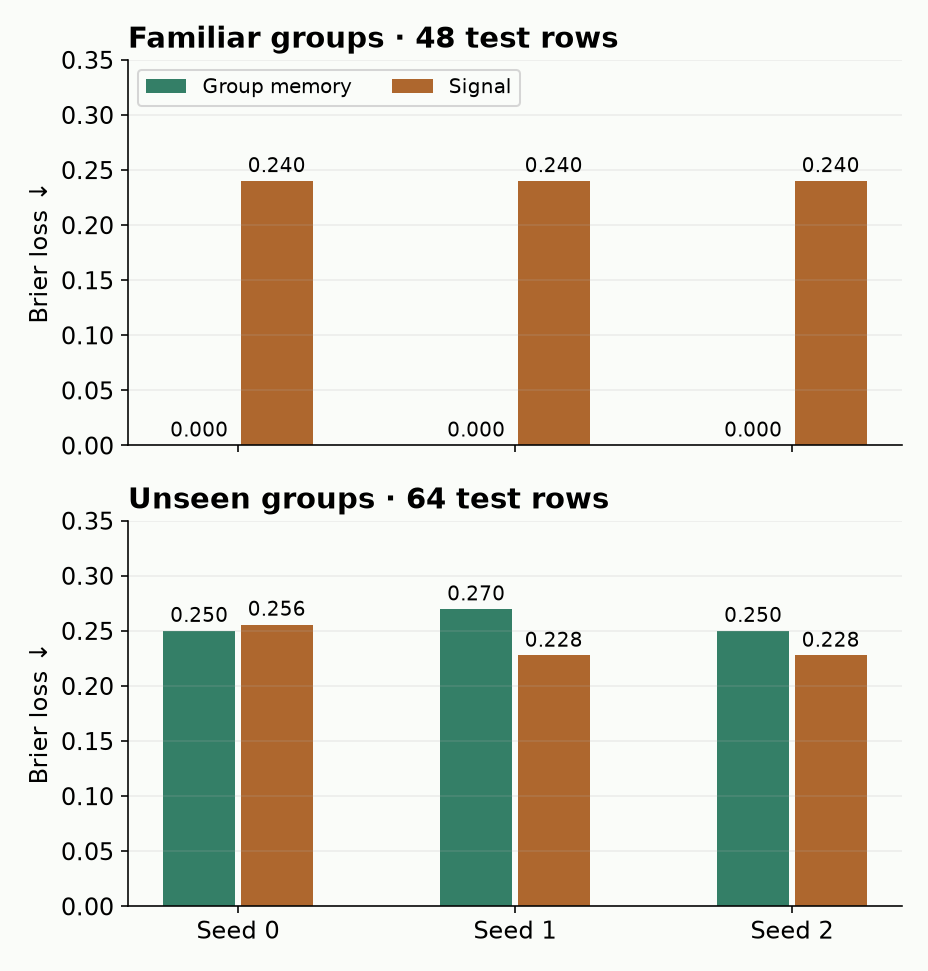<figcaption>Measured course diagnostic: shared groups yield perfect memory; unseen-group results vary by seed. On narrow screens, scroll the figure horizontally.</figcaption></figure>

| Seed | Random: memory | Random: signal | Grouped: memory | Grouped: signal |
|---:|---:|---:|---:|---:|
| 0 | 0.000000 | 0.240000 | 0.250000 | 0.255625 |
| 1 | 0.000000 | 0.240000 | 0.269531 | 0.227500 |
| 2 | 0.000000 | 0.240000 | 0.250000 | 0.227500 |


The group-memory rule is perfect under the random split. Under grouped testing it falls back to prevalence. The signal rule wins in two seeds and loses in one. This supports the mechanism—familiar groups can make a task easier—not a universal superiority claim about either predictor.

> **Scope check.** Test rows differ across regimes: 48 random-test rows versus 64 grouped-test rows. Comparing their losses changes the target population; it is not a paired same-row treatment estimate. Three synthetic seeds are not three independent real datasets. This diagnostic does not reproduce BeyondArena's models or datasets.

**Read the load-bearing code.** The notebook makes you implement the split audit; the experiment then calls it before scoring.

```python
train_groups = {by_id[i]["group"] for i in train_ids}
test_groups = {by_id[i]["group"] for i in test_ids}
overlap = train_groups & test_groups
```

Zero row overlap is insufficient. The group intersection answers the new-group question. Duplicate or unknown row IDs must fail before this calculation.

## 3 · A number needs an origin

BeyondArena's original report substitutes default Random Forest performance for certain unrun TabPFN-2.6 and TabDPT cases. That permits a complete comparison under a declared fallback policy, but it is not a measurement of the missing model. The current evaluator also exposes this policy in code. [Paper §5](https://arxiv.org/html/2606.30410v1#S5) · [Pinned evaluator context](https://github.com/autogluon/tabarena/blob/1ce4cae6c12972227dea6247bac83234a2915748/packages/tabarena/src/tabarena/contexts/beyondarena/context.py)

Separate three states: **measured**, **missing**, and **imputed** (filled by a declared rule). A fourth distinction is **replayed**: recalculating an aggregate from saved measurements creates no fresh model run.

**Worked example.** In our constructed four-dataset table, A has losses 0.10, 0.10, 0.10 and one missing result. B has 0.20 everywhere. The RF fallback for the missing dataset is 0.90. On the three jointly measured datasets A wins, 0.10 versus 0.20. After filling A's missing result, its mean is `(0.10 + 0.10 + 0.10 + 0.90) / 4 = 0.30`, so B wins.

**Predict before running:** trace the worked example, then compare your notebook outputs with this author reference.

<figure class="evidence-figure" tabindex="0" role="region" aria-label="Constructed losses: common measured support favors A; explicit RF substitution favors B." style="overflow-x:auto">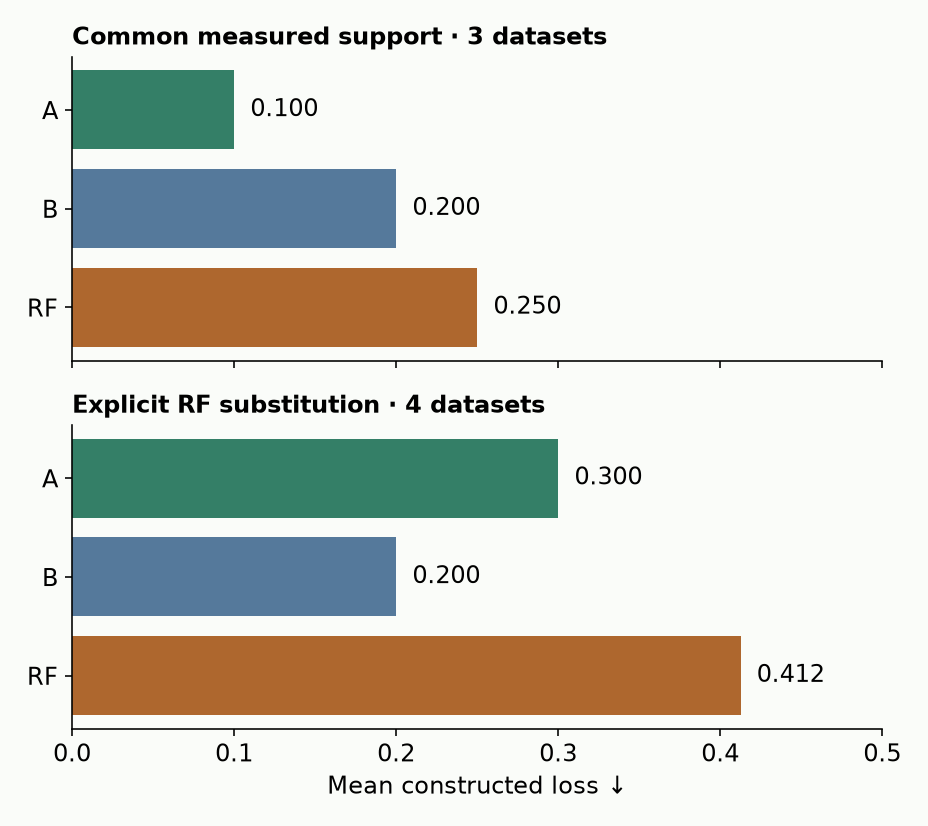<figcaption>Constructed losses: common measured support favors A; explicit RF substitution favors B. On narrow screens, scroll the figure horizontally.</figcaption></figure>

Neither policy discovers A's actual fourth score. Common support changes which datasets the claim covers; substitution changes which system produced part of the score. Keep the original missing cell and label the added value `imputed:RF`. Never silently replace it with a value marked `measured`.

These constructed losses share units. Real benchmark datasets can use different metrics and scales: do not average raw RMSE and AUROC error together. Ranking or normalized-error protocols need their own declared handling of ties, missing values and dataset weighting. Here “winner” means lowest mean constructed loss, not BeyondArena Elo.

## 4 · Nine seeds are not nine datasets

Suppose A−B loss differences are 0.10, 0.11, 0.09 on dataset a; −0.04, −0.05, −0.03 on b; and 0.02, 0.03, 0.01 on c. Positive means A has higher loss. Average seeds inside each dataset: the three means are 0.10, −0.04 and 0.02. Their equal-dataset mean is about 0.0267.

A **standard error** describes variability of an estimated mean under sampling assumptions. For independent dataset means, the familiar estimate is their sample standard deviation divided by the square root of the number of datasets. Seed runs share a dataset, so treating all nine rows as independent changes the assumption.

The fixture gives dataset-level SE ≈0.04055 versus naive seed-row SE ≈0.02048. Duplicating each seed result with a new seed ID makes the naive estimate smaller again, without adding a single dataset. Neither SE is a calibrated generalization guarantee: real datasets can share sources or tasks too.

**Predict before running:** trace the worked example, then compare your notebook outputs with this author reference.

<figure class="evidence-figure" tabindex="0" role="region" aria-label="Constructed paired differences: seed duplication shrinks only the naive row-based uncertainty." style="overflow-x:auto">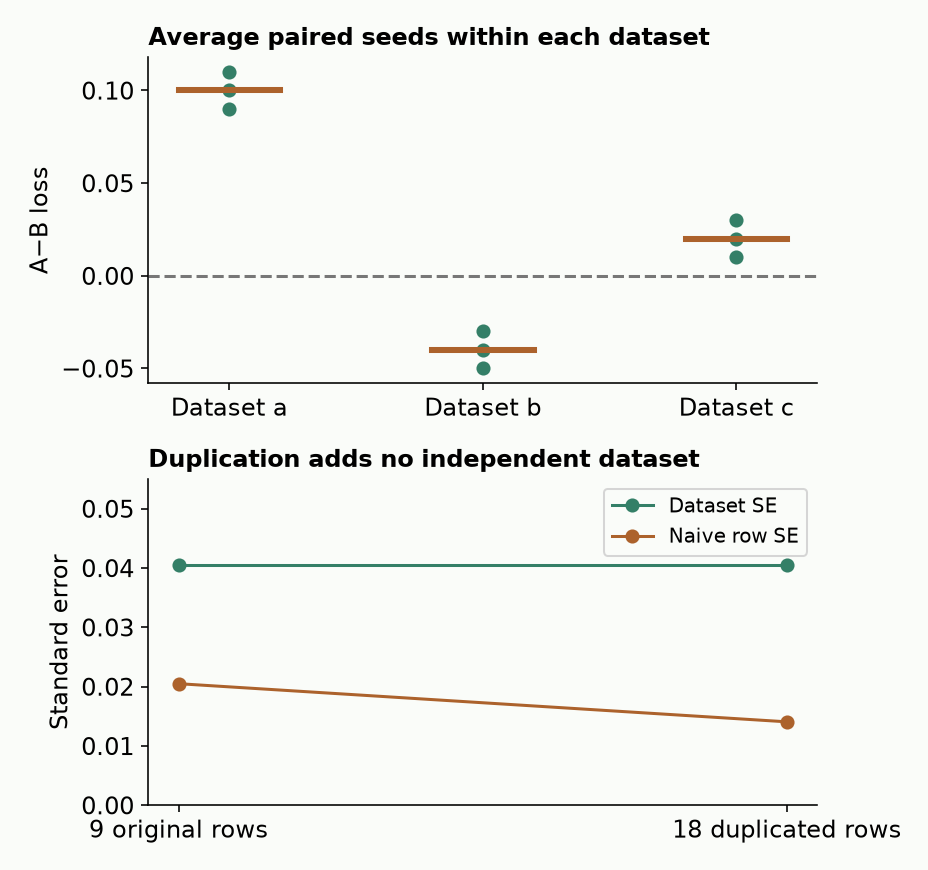<figcaption>Constructed paired differences: seed duplication shrinks only the naive row-based uncertainty. On narrow screens, scroll the figure horizontally.</figcaption></figure>

A **bootstrap** samples observed units with replacement. The lab enumerates all 27 ordered ways to resample three dataset means. As a teaching contrast, it also enumerates 729 ways to draw three of the nine seed rows. Both draws contain three units; the latter is deliberately not the usual nine-row bootstrap. The operation makes the choice of sampling unit visible. It does not turn this tiny constructed fixture into population evidence.

**CHECK.** If one dataset has 30 seeds and another has three, averaging all seed rows weights the first dataset ten times as heavily. Average within dataset first if the declared estimand—the quantity you want to estimate—is mean performance across equally weighted datasets. Report paired differences on common datasets; do not inflate the dataset count with folds, variants or repeated tasks.

## 5 · Contamination is a separate question from splitting

A correct test split cannot erase exposure during pretraining. **Contamination** means evaluation information has entered model development or training in a way that invalidates the claimed holdout. Distinguish these cases:

| Exposure | What to check | What the check does not establish |
|---|---|---|
| Test labels used in fitting/selection | Fit scopes, timestamps, trial logs | Pretraining cleanliness |
| Dataset used in pretraining | Training manifest, hashes, dataset lineage | Absence of renamed derivatives |
| Near-duplicate or transformed table | Row/column matching and feature/target summaries | Perfect detection under arbitrary transforms |
| Repeated benchmark-driven development | Versioned decisions and untouched holdout | Independence merely because weights were frozen for the last run |

TabDPT's contamination appendix describes several identity/statistics checks across training and evaluation tables. Hash equality detects identical bytes; unequal hashes alone cannot rule out reordered, renamed or transformed copies. Statistical similarity is a screening signal requiring investigation, not proof of leakage. [TabDPT Appendix B.1](https://arxiv.org/html/2410.18164v3#A2.SS1)

**Worked trace.** Reorder a training table and rename its columns. The file hash changes while its information can remain identical. Conversely, two independently collected binary tables can have equal row counts and similar feature means. A good audit preserves both kinds of uncertainty. Record `UNKNOWN` exposure when the pretraining manifest is unavailable; do not substitute “clean.”

## 6 · Version the claim, not just the model name

<section class="evidence-flow" aria-label="Versioned evidence"><div class="evidence-step"><strong>Original paper target</strong>v1 Figure F.2 · original six families · grouped and IID · original full split/variant set</div><div class="evidence-arrow" aria-hidden="true">↓</div><div class="evidence-step"><strong>Later release</strong>September Linear rerun · newer TFM entries · current default core subset. Record these as changes.</div><div class="evidence-arrow" aria-hidden="true">↓</div><div class="evidence-step"><strong>Comparison decision</strong>Match all relevant identities for a historical claim, or label a new comparison. A familiar method name cannot bridge changed protocols.</div></section>

A later model can solve an older failure without contradicting the older measurement. Freeze the paper version, model/checkpoint, dataset bytes, split IDs, support policy, preprocessing, candidate search, missing-result policy and metric. A version label alone does not authenticate the weights or test population.

The pinned current BeyondArena registry retains the original suite but replaces its default Linear entry with a September rerun. Its quickstart uses a reduced core set of splits. These are observable changes, not evidence that either version is invalid. Using today's defaults cannot automatically reproduce yesterday's figure. [Pinned registry](https://github.com/autogluon/tabarena/blob/1ce4cae6c12972227dea6247bac83234a2915748/packages/tabarena/src/tabarena/contexts/beyondarena/methods.py) · [Benchmark log](https://github.com/autogluon/tabarena/blob/1ce4cae6c12972227dea6247bac83234a2915748/packages/tabflow_slurm/BENCHMARK_LOG.md)

| Source or lane | Task/split and exposure | Selection and missing scores | Access / comparability |
|---|---|---|---|
| BeyondArena v1 | Mixed IID/grouped/temporal; audit each model's training exposure | Traditional search vs TFM ICL; specified RF fallbacks | Public source/results; historical F.2 IID scores not recovered here |
| Current pinned BeyondArena registry | Original and newer suites coexist; core differs from all splits | Linear rerun replaces default registry entry | Version change must be recorded before comparing ranks |
| TabDPT v3 | Real-data pretraining; Appendix B.1 overlap screening | Follow its own split, retrieval and selection protocol | Screening evidence is not proof of zero contamination |
| Enterprise study v1 | Selected internal business tasks; audit curation and semantic types | Nontrivial/signal filters affect target population | Internal data prevent an independent B19 reproduction; SAP affiliation disclosed |
| B19 synthetic diagnostic | Known generator; grouped/random populations; no pretraining | Fixed rules, all conditions, separate imputation fixture | Full local reconstruction; no real-data benchmark ranking |


The enterprise study's internal tasks were filtered for nontriviality and predictive signal. Its task composition and restricted data access must travel with any ranking claim. A vendor-affiliated study is not automatically wrong; affiliation and independent reproduction are separate fields in the matrix. Record categorical fraction, semantic types, imbalance, missingness, task mix and selection rules before transporting a ranking to your business problem. [Enterprise study §§3–5](https://arxiv.org/html/2606.30452v1#S3)

**Representativeness checklist.** Do not collapse strings, categories and identifiers into one feature type. For a business transfer claim, attach these fields to each compared suite:

| Field | BeyondArena evidence to inspect | Enterprise-study boundary |
|---|---|---|
| Task mix | 142 curated datasets spanning IID, grouped and temporal tasks | 557 selected internal tasks: 491 classification, 66 regression |
| Categorical fraction / semantic types | Per-task type metadata and actual preprocessing; one fraction cannot summarize the suite | String prevalence is not identical to categorical fraction; inspect semantic typing |
| Imbalance / missingness | Per-task minority fraction, imbalance ratio and missing-value fraction in the archived metadata | Aggregate distributions do not identify every task; internal row-level audit is not available here |
| Provider involvement | Authors include Prior Labs and academic researchers | SAP-affiliated internal-data study |
| Independent verification | B19 audits released grouped score tables, not fresh model outputs | B19 has not reproduced the internal benchmark |

[BeyondArena paper and affiliations](https://arxiv.org/html/2606.30410v1) · [Enterprise task counts and affiliations](https://arxiv.org/html/2606.30452v1)

Use [B03](https://avistian.github.io/relational/lessons/b03-pfn-tabpfn-generations.html) and [B06](https://avistian.github.io/relational/lessons/b06-mitra-prior-mixtures.html) as checks on historical model identity. Their diagnostic successes and original-paper source gaps remain separate. [TabBench](https://huggingface.co/spaces/Neuralk-AI/tabbench) is another benchmark to audit; B19 does not authenticate or reproduce its current ranking.

## 7 · Our full-reproduction ledger

**Named target:** BeyondArena v1 Figure F.2: two datasets, grouped and IID splits, six model families, with the original displayed variants and full protocol. The published rank correlations are targets to check, not newly measured B19 values.

| Evidence item | B19 status |
|---|---|
| Complete course diagnostic | 12 arms, 672 predictions independently reconstructed |
| Released grouped scores | 9,540 records; twelve default aggregates checked |
| Full Figure F.2 | INCOMPLETE_SOURCE_PROTOCOL_GATE / NOT_RUN |
| Fresh benchmark / pretraining | NOT_RUN |
| Learner defense / live Colab | PENDING_WRITTEN_DEFENSE / NOT_CHECKED |


We fetched all six original-suite model-result tables and corresponding HPO tables, plus metadata. The complete selected grouped extraction contains **9,540 score records**. It covers 60 musk folds and 30 SAT11 folds, 26 configurations for each of four classical models and one for each TFM. The audit authenticates bytes, checks complete keys, compares every selected record against its original table and recomputes twelve default means. It does not rescore original predictions.

**The missing half matters.** The fetched tables have no corresponding IID-ablation scores. Both IID curation notebooks exist, but their existence does not supply the missing results. UUID-based renaming in source notebooks also means rerunning them is not proof of identical historical input bytes. Our bounded artifact search does not prove that unpublished or differently hosted artifacts do not exist.

> **Scope check.** Full Figure F.2: `INCOMPLETE_SOURCE_PROTOCOL_GATE / NOT_RUN`. Fresh paper-model fits and the whole benchmark: `NOT_RUN`. The complete grouped score-table audit is a narrower success. The explicit paper command refuses rather than calling the grouped half a reproduced figure. $0 paid compute; all local attempts share a 3,600-second cap.



## Run contract

Self-contained NumPy + Python standard library. No repository paths, downloads, credentials or installs are required. Source-visible operations below produce the course experiment. Author figures above are saved references; your current kernel outputs below are new local diagnostic execution. No model benchmark is trained. Tested environment is recorded in the repository. Live Colab frontend remains NOT_CHECKED.

In [1]:
# @colab-bootstrap
import itertools,math,json,unittest,base64,gzip,hashlib
from pathlib import Path
import numpy as np

## PROVIDED · hand-computable behavioral checks

Checks exercise duplicate identities, group overlap, common support, imputation provenance and dataset weighting. They do not grant learner mastery.

In [2]:
class Boundaries(unittest.TestCase):
    def test_split(self):
        rows=[dict(id=i,group=i//2,y=i//2) for i in range(4)]
        self.assertEqual(split_audit(rows,[0,2],[1,3]),dict(train_n=2,test_n=2,overlap_groups=[0,1],group_disjoint=False))
        self.assertTrue(split_audit(rows,[0,1],[2,3])['group_disjoint'])
        for train,test in [([0,0],[1]),([0],[0]),([99],[1]),([],[1])]:
            with self.assertRaises(ValueError):split_audit(rows,train,test)
        with self.assertRaises(ValueError):split_audit(rows+[rows[0]],[0],[1])
    def test_pairs(self):
        rows=[dict(dataset=d,seed=0,model=m,loss=v,origin='missing' if v is None else 'measured') for d,vals in [('x',[.1,.2,.3]),('y',[None,.2,.9])] for m,v in zip(['A','B','RF'],vals)]
        a=paired_scores(rows,['A','B']);self.assertEqual(a['keys'],[['x',0]]);self.assertAlmostEqual(a['means']['A'],.1)
        b=paired_scores(rows,['A','B'],'rf');self.assertAlmostEqual(b['means']['A'],.5);self.assertEqual(b['cells'][-2]['origin'],'imputed:RF');self.assertEqual(b['cells'][-2]['model'],'A')
        for bad in [rows+[rows[0]],[dict(x,loss=float('nan')) if i==0 else x for i,x in enumerate(rows)],[dict(x,origin='measured') if x['loss'] is None else x for x in rows]]:
            with self.assertRaises(ValueError):paired_scores(bad,['A','B'])
        with self.assertRaises(ValueError):paired_scores(rows,['A','B'],'pretend')
        with self.assertRaises(ValueError):paired_scores(rows,['absent','B'],'rf')
    def test_datasets(self):
        rows=[dict(dataset=d,seed=s,delta=v) for d,vals in [('a',[.1,.2]),('b',[-.1,0])] for s,v in enumerate(vals)]
        r=dataset_summary(rows);self.assertEqual(r['n_datasets'],2);self.assertAlmostEqual(r['mean'],.05);self.assertAlmostEqual(r['se_dataset'],.1)
        doubled=rows+[dict(x,seed=x['seed']+2) for x in rows]
        rr=dataset_summary(doubled);self.assertEqual(rr['n_datasets'],2);self.assertAlmostEqual(rr['se_dataset'],r['se_dataset']);self.assertLess(rr['se_naive_rows'],r['se_naive_rows'])
        for bad in [[],rows+[rows[0]],rows+[dict(dataset='c',seed=0,delta=float('nan'))]]:
            with self.assertRaises(ValueError):dataset_summary(bad)


## SOLUTION · split_audit

Reject duplicate, overlapping, empty or unknown row IDs. Return train/test counts, sorted overlap_groups and group_disjoint. Do not reject group overlap: report it so the caller can assess its intended deployment.

In [3]:
def split_audit(rows, train_ids, test_ids):
    """Audit row identity separately from group separation; overlap is evidence."""
    by_id = {r['id']: r for r in rows}
    train, test = set(train_ids), set(test_ids)
    if len(by_id) != len(rows) or len(train) != len(train_ids) or len(test) != len(test_ids):
        raise ValueError('Duplicate row identity')
    if not train or not test or train & test or not (train | test) <= by_id.keys():
        raise ValueError('Empty, overlapping or unknown row IDs')
    overlap = sorted({by_id[i]['group'] for i in train} & {by_id[i]['group'] for i in test})
    return dict(train_n=len(train), test_n=len(test), overlap_groups=overlap, group_disjoint=not overlap)

### CHECK · run before continuing

In [4]:
Boundaries('test_split').debug()
print('split_audit: passed')

split_audit: passed


## SOLUTION · paired_scores

Validate explicit measured/missing origins and unique dataset/seed/model identities. For measured policy retain common measured support. For rf policy fill only declared missing cells using a measured same-key RF score, retaining origin imputed:RF. Return keys, cells, means and order. Reject absent identities rather than silently inventing missing runs.

In [5]:
def paired_scores(rows, models, policy='measured'):
    """Common measured support, or explicit RF substitution; never silent fill."""
    if policy not in ('measured', 'rf') or not models or len(set(models)) != len(models):
        raise ValueError('Invalid policy or model list')
    cells = {}
    for r in rows:
        key = (r['dataset'], r['seed'], r['model'])
        if key in cells:
            raise ValueError('Duplicate score identity')
        loss, origin = r['loss'], r['origin']
        if (loss is None and origin != 'missing') or (loss is not None and (origin != 'measured' or not math.isfinite(loss))):
            raise ValueError('Invalid score or origin')
        cells[key] = r
    keys = sorted({(r['dataset'], r['seed']) for r in rows})
    selected, used = [], []
    for dataset, seed in keys:
        current = []
        for model in models:
            row = cells.get((dataset, seed, model))
            if row is None:
                raise ValueError('Missing identity: declare missing runs explicitly')
            if row['loss'] is None:
                if policy == 'measured':
                    break
                rf = cells.get((dataset, seed, 'RF'))
                if rf is None or rf['loss'] is None:
                    raise ValueError('No measured RF substitute')
                row = dict(row, loss=rf['loss'], origin='imputed:RF')
            current.append(dict(row))
        if len(current) == len(models):
            selected.append([dataset, seed]); used.extend(current)
    if not selected:
        raise ValueError('No common support')
    means = {m: float(np.mean([r['loss'] for r in used if r['model'] == m])) for m in models}
    return dict(keys=selected, cells=used, means=means, order=sorted(models, key=lambda m: (means[m], m)))

### CHECK · run before continuing

In [6]:
Boundaries('test_pairs').debug()
print('paired_scores: passed')

paired_scores: passed


## SOLUTION · dataset_summary

Reject duplicate dataset/seed keys and nonfinite differences. Average seeds within dataset; return equal-dataset mean, dataset means/count and sample-SD/sqrt(n) standard error. Also return the explicitly naive row-level SE for comparison; return None when fewer than two units exist.

In [7]:
def dataset_summary(rows):
    """Equal weight per dataset after averaging seeds; seed rows are dependent."""
    if not rows:
        raise ValueError('No datasets')
    seen, grouped = set(), {}
    for r in rows:
        key = (r['dataset'], r['seed'])
        if key in seen or not math.isfinite(r['delta']):
            raise ValueError('Duplicate or nonfinite paired difference')
        seen.add(key); grouped.setdefault(r['dataset'], []).append(r['delta'])
    means = {d: float(np.mean(v)) for d, v in sorted(grouped.items())}
    n = len(means)
    se = float(np.std(list(means.values()), ddof=1) / np.sqrt(n)) if n > 1 else None
    naive = float(np.std([r['delta'] for r in rows], ddof=1) / np.sqrt(len(rows))) if len(rows) > 1 else None
    return dict(n_datasets=n, n_seed_rows=len(rows), dataset_means=means, mean=float(np.mean(list(means.values()))), se_dataset=se, se_naive_rows=naive)

### CHECK · run before continuing

In [8]:
Boundaries('test_datasets').debug()
print('dataset_summary: passed')

dataset_summary: passed


## PROVIDED · fixed synthetic data

No learner functions are hidden in an import. The group labels are generated once per seed; predictor inputs exclude query targets. Two held-out rows per group versus eight held-out groups deliberately test different populations. The group ID shortcut is an illustration, not a claim about musk features or a TFM.

In [9]:
def make_fixture(seed):
    rng = np.random.default_rng(seed)
    labels = rng.permutation([0]*12 + [1]*12)
    rows = [dict(id=8*g+j, group=g, y=int(labels[g]), signal=int(labels[g] if rng.random()<.7 else 1-labels[g])) for g in range(24) for j in range(8)]
    random_test = sorted(int(8*g+j) for g in range(24) for j in rng.choice(8, 2, replace=False))
    held_groups = set(int(g) for g in rng.choice(24, 8, replace=False))
    grouped_test = [r['id'] for r in rows if r['group'] in held_groups]
    return dict(seed=seed, rows=rows, tests=dict(random=random_test, grouped=grouped_test))

## PROVIDED · prediction and evidence aggregation

Trace the two prediction rules, then the scoring-only use of y. All three learner functions are called here. The separate uncertainty fixture has three constructed datasets, unlike the three seeds of the group fixture.

In [10]:
def run_experiment():
    fixtures, arms = [], []
    for seed in (0,1,2):
        f = make_fixture(seed); fixtures.append(f)
        for regime, test in f['tests'].items():
            train = [r['id'] for r in f['rows'] if r['id'] not in set(test)]
            audit = split_audit(f['rows'], train, test)
            train_rows = [f['rows'][i] for i in train]
            prevalence = float(np.mean([r['y'] for r in train_rows]))
            memory = {g: float(np.mean([r['y'] for r in train_rows if r['group']==g])) for g in {r['group'] for r in train_rows}}
            for model in ('group_memory','signal'):
                predictions = [dict(id=i, group=f['rows'][i]['group'], y=f['rows'][i]['y'], p=memory.get(f['rows'][i]['group'],prevalence) if model=='group_memory' else .2+.6*f['rows'][i]['signal']) for i in test]
                # Training-only predictor values; query labels enter scoring only.
                loss = float(np.mean([(p['p']-p['y'])**2 for p in predictions]))
                arms.append(dict(seed=seed, regime=regime, model=model, train_ids=train, audit=audit, predictions=predictions, brier=loss))
    score_rows = [dict(dataset=f'd{d}',seed=0,model=m,loss=v,origin='missing' if v is None else 'measured') for d,vals in enumerate(zip([.1,.1,.1,None],[.2]*4,[.25,.25,.25,.9])) for m,v in zip(['A','B','RF'],vals)]
    deltas = [dict(dataset=d,seed=s,delta=v) for d,values in [('a',[.10,.11,.09]),('b',[-.04,-.05,-.03]),('c',[.02,.03,.01])] for s,v in enumerate(values)]
    summary = dataset_summary(deltas)
    dataset_boot = sorted(float(np.mean(v)) for v in itertools.product(summary['dataset_means'].values(), repeat=3))
    row_three = sorted(float(np.mean(v)) for v in itertools.product([r['delta'] for r in deltas], repeat=3))
    duplicated = dataset_summary(deltas + [dict(r,seed=r['seed']+3) for r in deltas])
    return dict(protocol='B19-EVIDENCE-BOUNDARIES-v1',fixtures=fixtures,arms=arms,score_rows=score_rows,policies={p:paired_scores(score_rows,['A','B','RF'],p) for p in ('measured','rf')},deltas=deltas,uncertainty=summary,duplicated_seeds=duplicated,dataset_bootstrap=dataset_boot,three_row_resampling=row_three,paper='NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')

## RUN · the complete course experiment

In [11]:
report=run_experiment()
Path('b19-diagnostic.json').write_text(json.dumps(report,indent=2)+'\n')
assert len(report['arms'])==12
assert sum(len(a['predictions']) for a in report['arms'])==672
for a in report['arms']:
    print(a['seed'],a['regime'],a['model'],round(a['brier'],6))
print(report['uncertainty'])
print({p:r['means'] for p,r in report['policies'].items()})

0 random group_memory 0.0
0 random signal 0.24
0 grouped group_memory 0.25
0 grouped signal 0.255625
1 random group_memory 0.0
1 random signal 0.24
1 grouped group_memory 0.269531
1 grouped signal 0.2275
2 random group_memory 0.0
2 random signal 0.24
2 grouped group_memory 0.25
2 grouped signal 0.2275
{'n_datasets': 3, 'n_seed_rows': 9, 'dataset_means': {'a': 0.10000000000000002, 'b': -0.04, 'c': 0.02}, 'mean': 0.026666666666666672, 'se_dataset': 0.04055175020198814, 'se_naive_rows': 0.02048034287907418}
{'measured': {'A': 0.10000000000000002, 'B': 0.20000000000000004, 'RF': 0.25}, 'rf': {'A': 0.30000000000000004, 'B': 0.2, 'RF': 0.4125}}


## Paper lane · portable saved-score replay

The embedded compact packet contains all 9,540 selected grouped score records, with dataset/fold/configuration keys and original suite labels. Its SHA256 checks packet identity; visible code checks complete coverage and recomputes twelve default means. This portable lane does not authenticate the full source Parquet extraction: the repository audit does that separately. No IID-ablation scores or raw predictions are embedded, and no paper model is fitted.

In [12]:
compact=base64.b64decode('...')
assert hashlib.sha256(compact).hexdigest()=='23291edb629fc47863effdc67a2fe39e2a5e12c7aad30142d9073b6db970dcb1'
records=json.loads(gzip.decompress(compact))
assert len(records)==9540

In [13]:
def replay_grouped(records):
    """Recompute every default mean; authenticate full 26-config/1-config coverage."""
    groups={};keys=set()
    for r in records:
        key=(r['dataset'],r['fold'],r['method'])
        if key in keys or not math.isfinite(r['metric_error']):raise ValueError('Duplicate or invalid published score')
        keys.add(key)
        if r['ta_suite']!='beyond_iid_benchmark_2026':raise ValueError('Wrong source suite')
        groups.setdefault((r['dataset'],r['ta_name']),[]).append(r)
    expected_models={'LinearModel','ExtraTrees','LightGBM','TA-RealMLP','TA-TabPFN-2.6','TA-TabICLv2'}
    expected_datasets={'musk-16dca0dbddf5','sat11_hand_algo_runtime-cda3af888024'}
    if set(groups)!={(d,m) for d in expected_datasets for m in expected_models}:raise ValueError('Incomplete selected matrix')
    result=[]
    for (d,m),rows in sorted(groups.items()):
        n=60 if d.startswith('musk') else 30;configs=1 if m in ['TA-TabPFN-2.6','TA-TabICLv2'] else 26
        # Actual naming is audited below by count and complete per-config folds; do not infer search values from names.
        names={r['method'] for r in rows}
        if len(rows)!=n*configs or len(names)!=configs:raise ValueError('Wrong config count')
        for name in names:
            if {r['fold'] for r in rows if r['method']==name}!=set(range(n)):raise ValueError('Missing original fold')
        metric='roc_auc' if d.startswith('musk') else 'rmse'
        if {r['metric'] for r in rows}!={metric}:raise ValueError('Wrong metric')
        default=[r['metric_error'] for r in rows if r['method']==m+'_c1_BAG_L1']
        if len(default)!=n:raise ValueError('Missing default config')
        result.append(dict(dataset=d,model=m,folds=n,metric=metric,mean_error=sum(default)/n))
    return result

In [14]:
grouped_summary=replay_grouped(records)
Path('b19-grouped-summary.json').write_text(json.dumps(grouped_summary,indent=2)+'\n')
for row in grouped_summary:
    print(row['dataset'],row['model'],row['folds'],row['metric'],round(row['mean_error'],6))
print('COMPLETE_SELECTED_SCORE_TABLE_AUDIT; full Figure F.2 INCOMPLETE_SOURCE_PROTOCOL_GATE / NOT_RUN')

musk-16dca0dbddf5 ExtraTrees 60 roc_auc 0.153752
musk-16dca0dbddf5 LightGBM 60 roc_auc 0.20147
musk-16dca0dbddf5 LinearModel 60 roc_auc 0.171525
musk-16dca0dbddf5 TA-RealMLP 60 roc_auc 0.143173
musk-16dca0dbddf5 TA-TabICLv2 60 roc_auc 0.126117
musk-16dca0dbddf5 TA-TabPFN-2.6 60 roc_auc 0.16039
sat11_hand_algo_runtime-cda3af888024 ExtraTrees 30 rmse 2.063864
sat11_hand_algo_runtime-cda3af888024 LightGBM 30 rmse 2.235854
sat11_hand_algo_runtime-cda3af888024 LinearModel 30 rmse 3.75706
sat11_hand_algo_runtime-cda3af888024 TA-RealMLP 30 rmse 2.109638
sat11_hand_algo_runtime-cda3af888024 TA-TabICLv2 30 rmse 2.135742
sat11_hand_algo_runtime-cda3af888024 TA-TabPFN-2.6 30 rmse 1.976293
COMPLETE_SELECTED_SCORE_TABLE_AUDIT; full Figure F.2 INCOMPLETE_SOURCE_PROTOCOL_GATE / NOT_RUN


## EXIT · produce your own preregistration

Choose an untouched accessible grouped or temporal task. Before test access, specify its deployment population, full identities and label-availability times, inner/outer splits, baseline/challenger versions and pretraining exposure, accessible support/features, preprocessing/search/refit rules, seed and total compute budget, primary metric, paired support, missing-run policy, independent unit and falsification criterion. This notebook has not run that new task. Explain in 150–200 words why the 9,540 saved scores do not establish full Figure F.2 reproduction. Ask the teacher to review your contract and revisit after 1/7/30 days.

In [15]:
print('Author diagnostic complete; learner PENDING_WRITTEN_DEFENSE; paid compute USD0; full paper NOT_RUN')

Author diagnostic complete; learner PENDING_WRITTEN_DEFENSE; paid compute USD0; full paper NOT_RUN
